In [103]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import SelectKBest, f_classif

import shap

In [148]:
telco_data = pd.read_csv("../data/processed/feature_engineered_customers.csv")

In [149]:
telco_data.shape

(7043, 32)

In [150]:
telco_data.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'TenureGroup',
 'NumberOfServices',
 'IsDSL',
 'IsFiberOptic',
 'NoInternet',
 'MonthlyChargesGroup',
 'TotalChargesGroup',
 'ChargeToTenureRatio',
 'HighValueCustomer',
 'HighRiskCustomer',
 'InternetTechSupport']

In [151]:
telco_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,NumberOfServices,IsDSL,IsFiberOptic,NoInternet,MonthlyChargesGroup,TotalChargesGroup,ChargeToTenureRatio,HighValueCustomer,HighRiskCustomer,InternetTechSupport
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,2,1,0,0,Low,Low,29.850000,0,0,Internet_Without_Support
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,3,1,0,0,Medium,Medium,55.573529,0,0,Internet_Without_Support
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,3,1,0,0,Medium,Low,54.075000,0,0,Internet_Without_Support
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,4,1,0,0,Medium,Medium,40.905556,0,0,Internet_With_Support
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,1,0,1,0,High,Low,75.825000,0,1,Internet_Without_Support


In [152]:
x = telco_data.drop(columns=["Churn", "customerID"])
y = telco_data["Churn"].map({"No": 0, "Yes": 1})

In [153]:
print("X shape:", x.shape)
print("y shape:", y.shape)
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

X shape: (7043, 30)
y shape: (7043,)
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


In [154]:
categorical_features = x.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_features

C:\Users\SURYA\AppData\Local\Temp\ipykernel_5348\1447111206.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = x.select_dtypes(include=["object", "category"]).columns.tolist()


['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TenureGroup',
 'MonthlyChargesGroup',
 'TotalChargesGroup',
 'InternetTechSupport']

In [155]:
x_encoded = pd.get_dummies(
    x,
    columns=categorical_features,
    drop_first=False,
    dtype=int
)
x_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,NumberOfServices,IsDSL,IsFiberOptic,NoInternet,ChargeToTenureRatio,HighValueCustomer,...,TenureGroup_Very Long Term,MonthlyChargesGroup_High,MonthlyChargesGroup_Low,MonthlyChargesGroup_Medium,TotalChargesGroup_High,TotalChargesGroup_Low,TotalChargesGroup_Medium,InternetTechSupport_Internet_With_Support,InternetTechSupport_Internet_Without_Support,InternetTechSupport_No_Internet
0,0,1,29.85,29.85,2,1,0,0,29.850000,0,...,0,0,1,0,0,1,0,0,1,0
1,0,34,56.95,1889.50,3,1,0,0,55.573529,0,...,0,0,0,1,0,0,1,0,1,0
2,0,2,53.85,108.15,3,1,0,0,54.075000,0,...,0,0,0,1,0,1,0,0,1,0
3,0,45,42.30,1840.75,4,1,0,0,40.905556,0,...,0,0,0,1,0,0,1,1,0,0
4,0,2,70.70,151.65,1,0,1,0,75.825000,0,...,0,1,0,0,0,1,0,0,1,0


In [156]:
X_train, X_test, y_train, y_test = train_test_split(
    x_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5634, 66)
X_test shape: (1409, 66)


In [157]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_features

['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'NumberOfServices',
 'IsDSL',
 'IsFiberOptic',
 'NoInternet',
 'ChargeToTenureRatio',
 'HighValueCustomer',
 'HighRiskCustomer',
 'gender_Female',
 'gender_Male',
 'Partner_No',
 'Partner_Yes',
 'Dependents_No',
 'Dependents_Yes',
 'PhoneService_No',
 'PhoneService_Yes',
 'MultipleLines_No',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_DSL',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes',
 'Contract_Month

In [158]:
scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

X_test[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

print("Numerical scaled")

Numerical scaled


In [159]:
os.makedirs("../models", exist_ok=True)
joblib.dump(scaler, "../models/xgb_scaler.pkl")

print("saved")

saved


In [160]:
joblib.dump(numeric_features, "../models/xgb_numeric_features.pkl")
print("saved")

saved


In [161]:
joblib.dump(X_train.columns.tolist(), "../models/xgb_training_columns.pkl")
print("saved")

saved


In [13]:
print(X_train[numeric_features].mean().round(2))
print(X_train[numeric_features].std().round(2))

SeniorCitizen                                   0.0
tenure                                         -0.0
MonthlyCharges                                 -0.0
TotalCharges                                   -0.0
NumberOfServices                                0.0
                                               ... 
TotalChargesGroup_Low                           0.0
TotalChargesGroup_Medium                       -0.0
InternetTechSupport_Internet_With_Support      -0.0
InternetTechSupport_Internet_Without_Support   -0.0
InternetTechSupport_No_Internet                -0.0
Length: 66, dtype: float64
SeniorCitizen                                   1.0
tenure                                          1.0
MonthlyCharges                                  1.0
TotalCharges                                    1.0
NumberOfServices                                1.0
                                               ... 
TotalChargesGroup_Low                           1.0
TotalChargesGroup_Medium             

### ML MODELS

In [14]:
def evaluate_model(model, X_test, y_test):
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Prediction probabilities
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    
    # Display results
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))
    print("PR-AUC   :", round(pr_auc, 4))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }

### Logistics Regression

In [15]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [16]:
logistic_results = evaluate_model(logistic_model, X_test, y_test)

Accuracy : 0.8006
Precision: 0.6555
Recall   : 0.5241
F1 Score : 0.5825
ROC-AUC  : 0.841
PR-AUC   : 0.6349

Confusion Matrix:
[[932 103]
 [178 196]]


### Decision Tree

In [17]:
decision_tree_model = DecisionTreeClassifier( random_state=42)
decision_tree_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

In [18]:
decision_tree_results = evaluate_model(decision_tree_model, X_test, y_test)

Accuracy : 0.7019
Precision: 0.4425
Recall   : 0.4733
F1 Score : 0.4574
ROC-AUC  : 0.6286
PR-AUC   : 0.3492

Confusion Matrix:
[[812 223]
 [197 177]]


#### KNN 

In [19]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [20]:
knn_results = evaluate_model(knn_model, X_test, y_test)

Accuracy : 0.7821
Precision: 0.5965
Recall   : 0.5535
F1 Score : 0.5742
ROC-AUC  : 0.7899
PR-AUC   : 0.5344

Confusion Matrix:
[[895 140]
 [167 207]]


### Random Forest

In [21]:
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
random_forest_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [22]:
random_forest_results = evaluate_model(random_forest_model, X_test, y_test)

Accuracy : 0.7807
Precision: 0.6066
Recall   : 0.4947
F1 Score : 0.5449
ROC-AUC  : 0.8205
PR-AUC   : 0.6104

Confusion Matrix:
[[915 120]
 [189 185]]


### Gradient Boosting

In [23]:
gradient_boosting_model = GradientBoostingClassifier( n_estimators=100, learning_rate=0.1, random_state=42)
gradient_boosting_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [24]:
gradient_boosting_results = evaluate_model(gradient_boosting_model, X_test, y_test)

Accuracy : 0.8006
Precision: 0.6643
Recall   : 0.5027
F1 Score : 0.5723
ROC-AUC  : 0.8443
PR-AUC   : 0.6564

Confusion Matrix:
[[940  95]
 [186 188]]


### XGBoost

In [25]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [26]:
xgb_results = evaluate_model(xgb_model, X_test, y_test)

Accuracy : 0.797
Precision: 0.6507
Recall   : 0.508
F1 Score : 0.5706
ROC-AUC  : 0.8457
PR-AUC   : 0.6595

Confusion Matrix:
[[933 102]
 [184 190]]


In [27]:
results = []
results.append({
    "Model": "Logistic Regression",
    **logistic_results
})
results.append({
    "Model": "Decision Tree",
    **decision_tree_results
})
results.append({
    "Model": "KNN",
    **knn_results
})
results.append({
    "Model": "Random Forest",
    **random_forest_results
})
results.append({
    "Model": "Gradient Boosting",
    **gradient_boosting_results
})
results.append({
    "Model": "XGBoost",
    **xgb_results
})

In [28]:
model_results = pd.DataFrame(results)
model_results.round(5)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.80057,0.65552,0.52406,0.58247,0.84099,0.63492
1,Decision Tree,0.70192,0.44250,0.47326,0.45736,0.62865,0.34923
2,KNN,0.78211,0.59654,0.55348,0.57420,0.78990,0.53439
3,Random Forest,0.78070,0.60656,0.49465,0.54492,0.82050,0.61042
4,Gradient Boosting,0.80057,0.66431,0.50267,0.57230,0.84429,0.65642
5,XGBoost,0.79702,0.65068,0.50802,0.57057,0.84567,0.65945


In [29]:
model_results.to_csv("../data/processed/baseline_model_results.csv", index=False)
print("Saved")

Saved


In [108]:
joblib.dump(logistic_model, "../models/logistic_model.pkl")
joblib.dump(decision_tree_model, "../models/decision_tree_model.pkl")
joblib.dump(knn_model, "../models/knn_model.pkl")
joblib.dump(random_forest_model, "../models/random_forest_model.pkl")
joblib.dump(gradient_boosting_model, "../models/gradient_boosting_model.pkl")
joblib.dump(xgb_model, "../models/xgb_model.pkl")

print('saved')

saved


## Model Improvement

### Cross Validtaion

In [30]:
models = {
    "Logistic Regression": logistic_model,
    "Gradient Boosting": gradient_boosting_model,
    "XGBoost": xgb_model
}

In [31]:
cv_scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [32]:
cv_results = []
for model_name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring=cv_scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Accuracy Std": scores["test_accuracy"].std(),
        "CV Precision Mean": scores["test_precision"].mean(),
        "CV Precision Std": scores["test_precision"].std(),
        "CV Recall Mean": scores["test_recall"].mean(),
        "CV Recall Std": scores["test_recall"].std(),
        "CV F1 Mean": scores["test_f1"].mean(),
        "CV F1 Std": scores["test_f1"].std(),
        "CV ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "CV ROC-AUC Std": scores["test_roc_auc"].std(),
        "CV PR-AUC Mean": scores["test_pr_auc"].mean(),
        "CV PR-AUC Std": scores["test_pr_auc"].std()
    })

In [33]:
cv_df = pd.DataFrame(cv_results)
cv_df

,Model,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Precision Std,CV Recall Mean,CV Recall Std,CV F1 Mean,CV F1 Std,CV ROC-AUC Mean,CV ROC-AUC Std,CV PR-AUC Mean,CV PR-AUC Std
0,Logistic Regression,0.803512,0.012935,0.665644,0.034798,0.524415,0.024247,0.586214,0.024196,0.845606,0.014545,0.664530,0.031818
1,Gradient Boosting,0.800139,0.014906,0.659781,0.037684,0.511706,0.037422,0.575741,0.032751,0.845621,0.014114,0.661379,0.033491
2,XGBoost,0.802801,0.017362,0.663852,0.041614,0.521070,0.037267,0.583570,0.037324,0.845565,0.014848,0.658851,0.033043


In [34]:
cv_df.to_csv("../data/processed/mdl_improvement_cross_validation.csv", index=False)
print("Saved")

Saved


### Class weight

In [35]:
#Logistic regression

In [36]:
logistic_balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_balanced_model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

In [37]:
logistic_balanced_results = evaluate_model(
    logistic_balanced_model,
    X_test,
    y_test
)

Accuracy : 0.7339
Precision: 0.4991
Recall   : 0.7781
F1 Score : 0.6082
ROC-AUC  : 0.8406
PR-AUC   : 0.6328

Confusion Matrix:
[[743 292]
 [ 83 291]]


In [38]:
# Gradient Boosting

In [39]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

weight_for_negative = 1
weight_for_positive = negative_count / positive_count

sample_weights = np.where(
    y_train == 1,
    weight_for_positive,
    weight_for_negative
)

In [40]:
gradient_boosting_balanced_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gradient_boosting_balanced_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [41]:
gradient_boosting_balanced_results = evaluate_model(
    gradient_boosting_balanced_model,
    X_test,
    y_test
)

Accuracy : 0.7509
Precision: 0.5204
Recall   : 0.7861
F1 Score : 0.6262
ROC-AUC  : 0.8417
PR-AUC   : 0.6561

Confusion Matrix:
[[764 271]
 [ 80 294]]


In [42]:
# XGBoost

In [43]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

xgb_balanced_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_balanced_model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [44]:
xgb_balanced_results = evaluate_model(
    xgb_balanced_model,
    X_test,
    y_test
)

Accuracy : 0.7523
Precision: 0.522
Recall   : 0.7941
F1 Score : 0.6299
ROC-AUC  : 0.8446
PR-AUC   : 0.6603

Confusion Matrix:
[[763 272]
 [ 77 297]]


In [45]:
balanced_results = [
    {
        "Model": "Logistic Regression - Balanced",
        **logistic_balanced_results
    },
    {
        "Model": "Gradient Boosting - Balanced",
        **gradient_boosting_balanced_results
    },
    {
        "Model": "XGBoost - Balanced",
        **xgb_balanced_results
    }
]

balanced_results_df = pd.DataFrame(balanced_results)
display(balanced_results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression - Balanced,0.733854,0.499142,0.778075,0.608150,0.840647,0.632751
1,Gradient Boosting - Balanced,0.750887,0.520354,0.786096,0.626198,0.841716,0.656117
2,XGBoost - Balanced,0.752307,0.521968,0.794118,0.629905,0.844562,0.660251


In [46]:
balanced_results_df.to_csv("../data/processed/model_improvement_balanced_results.csv", index=False)

### Hyperparameter tuning

In [47]:
# xgboost

In [48]:
xgb_param_grid = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_distributions=xgb_param_grid,
    n_iter=10,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgb_random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for m

In [49]:
print(xgb_random_search.best_params_)
print(round(xgb_random_search.best_score_, 4))

{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
0.5861


In [50]:
tuned_xgb_model = xgb_random_search.best_estimator_
tuned_xgb_results = evaluate_model(
    tuned_xgb_model,
    X_test,
    y_test
)

Accuracy : 0.797
Precision: 0.656
Recall   : 0.4947
F1 Score : 0.564
ROC-AUC  : 0.8444
PR-AUC   : 0.661

Confusion Matrix:
[[938  97]
 [189 185]]


In [51]:
# Logistic Regression

In [52]:
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"]
}

lr_random_search = RandomizedSearchCV(
    estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    param_distributions=lr_param_grid,
    n_iter=10,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

lr_random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attribute

In [53]:

print(lr_random_search.best_params_)
print(round(lr_random_search.best_score_, 4))

{'solver': 'lbfgs', 'class_weight': 'balanced', 'C': 0.01}
0.6292


In [54]:
tuned_lr_model = lr_random_search.best_estimator_

tuned_lr_results = evaluate_model(
    tuned_lr_model,
    X_test,
    y_test
)

Accuracy : 0.736
Precision: 0.5017
Recall   : 0.7834
F1 Score : 0.6117
ROC-AUC  : 0.8392
PR-AUC   : 0.625

Confusion Matrix:
[[744 291]
 [ 81 293]]


In [55]:
# Gradient Boosting

In [56]:
gb_param_grid = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.8, 1.0]
}

gb_random_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(
        random_state=42
    ),
    param_distributions=gb_param_grid,
    n_iter=10,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

gb_random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for 

In [57]:
print(gb_random_search.best_params_)
print(round(gb_random_search.best_score_, 4))

{'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 4, 'learning_rate': 0.05}
0.5777


In [58]:
tuned_gb_model = gb_random_search.best_estimator_

tuned_gb_results = evaluate_model(
    tuned_gb_model,
    X_test,
    y_test
)

Accuracy : 0.7991
Precision: 0.6564
Recall   : 0.5107
F1 Score : 0.5744
ROC-AUC  : 0.8437
PR-AUC   : 0.6475

Confusion Matrix:
[[935 100]
 [183 191]]


In [59]:
tuned_results = [
    {
        "Model": "Logistic Regression - Tuned",
        **tuned_lr_results
    },
    {
        "Model": "Gradient Boosting - Tuned",
        **tuned_gb_results
    },
    {
        "Model": "XGBoost - Tuned",
        **tuned_xgb_results
    }
]

tuned_results_df = pd.DataFrame(tuned_results)
display(tuned_results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression - Tuned,0.735983,0.501712,0.783422,0.611691,0.839223,0.625025
1,Gradient Boosting - Tuned,0.799148,0.656357,0.510695,0.574436,0.843667,0.647452
2,XGBoost - Tuned,0.797019,0.656028,0.494652,0.564024,0.844429,0.660957


In [60]:
tuned_results_df.to_csv("../data/processed/strong_models_tuned_results.csv", index=False)
print("Tuned results saved")

Tuned results saved


### Feature Selection

In [61]:
# xgboost

In [62]:
k_values = [10, 20, 30, 40]

xgb_feature_results = []

for k in k_values:

    selector_xgb = SelectKBest(
        score_func=f_classif,
        k=k
    )

    X_train_selected = selector_xgb.fit_transform(
        X_train, y_train
    )

    X_test_selected = selector_xgb.transform(
        X_test
    )

    feature_xgb_model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss"
    )

    feature_xgb_model.fit(
        X_train_selected,
        y_train
    )

    results = evaluate_model(
        feature_xgb_model,
        X_test_selected,
        y_test
    )

    xgb_feature_results.append({
        "Model": f"XGBoost Balanced - Feature Selected k={k}",
        **results
    })

Accuracy : 0.7445
Precision: 0.5122
Recall   : 0.7834
F1 Score : 0.6195
ROC-AUC  : 0.8366
PR-AUC   : 0.6428

Confusion Matrix:
[[756 279]
 [ 81 293]]
Accuracy : 0.7452
Precision: 0.513
Recall   : 0.7888
F1 Score : 0.6217
ROC-AUC  : 0.839
PR-AUC   : 0.6484

Confusion Matrix:
[[755 280]
 [ 79 295]]
Accuracy : 0.7495
Precision: 0.5181
Recall   : 0.8021
F1 Score : 0.6296
ROC-AUC  : 0.8403
PR-AUC   : 0.6635

Confusion Matrix:
[[756 279]
 [ 74 300]]
Accuracy : 0.7466
Precision: 0.5147
Recall   : 0.7968
F1 Score : 0.6254
ROC-AUC  : 0.8409
PR-AUC   : 0.6621

Confusion Matrix:
[[754 281]
 [ 76 298]]


In [63]:
xgb_feature_results_df = pd.DataFrame(xgb_feature_results)
display(xgb_feature_results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,XGBoost Balanced - Feature Selected k=10,0.744500,0.512238,0.783422,0.619450,0.836583,0.642810
1,XGBoost Balanced - Feature Selected k=20,0.745209,0.513043,0.788770,0.621707,0.838957,0.648438
2,XGBoost Balanced - Feature Selected k=30,0.749468,0.518135,0.802139,0.629591,0.840284,0.663515
3,XGBoost Balanced - Feature Selected k=40,0.746629,0.514680,0.796791,0.625393,0.840856,0.662093


In [64]:
xgb_feature_results_df.to_csv("../data/processed/xgb_feature_selection_results.csv", index=False)
print("saved")

saved


In [65]:
# GRADIENT BOOSTING

In [66]:
k_values = [10, 20, 30, 40]

gb_feature_results = []

for k in k_values:

    selector_gb = SelectKBest(
        score_func=f_classif,
        k=k
    )

    X_train_selected = selector_gb.fit_transform(
        X_train, y_train
    )

    X_test_selected = selector_gb.transform(
        X_test
    )

    feature_gb_model = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )

    feature_gb_model.fit(
        X_train_selected,
        y_train,
        sample_weight=sample_weights
    )

    results = evaluate_model(
        feature_gb_model,
        X_test_selected,
        y_test
    )

    gb_feature_results.append({
        "Model": f"Gradient Boosting - Feature Selected k={k}",
        **results
    })

gb_feature_results_df = pd.DataFrame(gb_feature_results)
display(gb_feature_results_df)

Accuracy : 0.7495
Precision: 0.5186
Recall   : 0.7834
F1 Score : 0.6241
ROC-AUC  : 0.8364
PR-AUC   : 0.641

Confusion Matrix:
[[763 272]
 [ 81 293]]
Accuracy : 0.741
Precision: 0.5078
Recall   : 0.7861
F1 Score : 0.617
ROC-AUC  : 0.8371
PR-AUC   : 0.6474

Confusion Matrix:
[[750 285]
 [ 80 294]]
Accuracy : 0.7495
Precision: 0.5185
Recall   : 0.7861
F1 Score : 0.6249
ROC-AUC  : 0.8388
PR-AUC   : 0.6595

Confusion Matrix:
[[762 273]
 [ 80 294]]
Accuracy : 0.7459
Precision: 0.5138
Recall   : 0.7941
F1 Score : 0.6239
ROC-AUC  : 0.8385
PR-AUC   : 0.6568

Confusion Matrix:
[[754 281]
 [ 77 297]]


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Gradient Boosting - Feature Selected k=10,0.749468,0.518584,0.783422,0.624068,0.836449,0.641023
1,Gradient Boosting - Feature Selected k=20,0.740951,0.507772,0.786096,0.616999,0.837062,0.647396
2,Gradient Boosting - Feature Selected k=30,0.749468,0.518519,0.786096,0.624867,0.838798,0.659461
3,Gradient Boosting - Feature Selected k=40,0.745919,0.513841,0.794118,0.623950,0.838539,0.656803


In [67]:
# LOGISTIC REGRESSION

In [68]:
k_values = [10, 20, 30, 40]

lr_feature_results = []

for k in k_values:

    selector_lr = SelectKBest(
        score_func=f_classif,
        k=k
    )

    X_train_selected = selector_lr.fit_transform(
        X_train, y_train
    )

    X_test_selected = selector_lr.transform(
        X_test
    )

    feature_lr_model = LogisticRegression(
        C=0.01,
        solver="lbfgs",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    )

    feature_lr_model.fit(
        X_train_selected,
        y_train
    )

    results = evaluate_model(
        feature_lr_model,
        X_test_selected,
        y_test
    )

    lr_feature_results.append({
        "Model": f"Logistic Regression - Feature Selected k={k}",
        **results
    })

lr_feature_results_df = pd.DataFrame(lr_feature_results)

display(lr_feature_results_df)

Accuracy : 0.7551
Precision: 0.526
Recall   : 0.7834
F1 Score : 0.6294
ROC-AUC  : 0.8344
PR-AUC   : 0.6315

Confusion Matrix:
[[771 264]
 [ 81 293]]
Accuracy : 0.7438
Precision: 0.5114
Recall   : 0.7807
F1 Score : 0.618
ROC-AUC  : 0.836
PR-AUC   : 0.6326

Confusion Matrix:
[[756 279]
 [ 82 292]]
Accuracy : 0.7395
Precision: 0.5059
Recall   : 0.7968
F1 Score : 0.6189
ROC-AUC  : 0.8366
PR-AUC   : 0.6294

Confusion Matrix:
[[744 291]
 [ 76 298]]
Accuracy : 0.7395
Precision: 0.506
Recall   : 0.7914
F1 Score : 0.6173
ROC-AUC  : 0.8361
PR-AUC   : 0.6265

Confusion Matrix:
[[746 289]
 [ 78 296]]


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression - Feature Selected k=10,0.755145,0.526032,0.783422,0.629431,0.834385,0.631547
1,Logistic Regression - Feature Selected k=20,0.743790,0.511384,0.780749,0.617989,0.835966,0.632601
2,Logistic Regression - Feature Selected k=30,0.739532,0.505942,0.796791,0.618899,0.836594,0.629354
3,Logistic Regression - Feature Selected k=40,0.739532,0.505983,0.791444,0.617310,0.836090,0.626549


### Threshold Optimization

In [69]:
# LOGISTIC REGRESSION

In [70]:
selector_lr_final = SelectKBest(
    score_func=f_classif,
    k=10
)

X_train_lr_selected = selector_lr_final.fit_transform(
    X_train, y_train
)

X_test_lr_selected = selector_lr_final.transform(
    X_test
)

final_lr_feature_model = LogisticRegression(
    C=0.01,
    solver="lbfgs",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

final_lr_feature_model.fit(
    X_train_lr_selected,
    y_train
)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to 

In [71]:
lr_prob = final_lr_feature_model.predict_proba(
    X_test_lr_selected
)[:, 1]

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

lr_threshold_results = []

for threshold in thresholds:

    y_pred = (lr_prob >= threshold).astype(int)

    lr_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

lr_threshold_results_df = pd.DataFrame(lr_threshold_results)
display(lr_threshold_results_df)

,Threshold,Precision,Recall,F1 Score
0,0.30,0.414663,0.922460,0.572139
1,0.35,0.437500,0.898396,0.588441
2,0.40,0.469208,0.855615,0.606061
3,0.45,0.488746,0.812834,0.610442
4,0.50,0.526032,0.783422,0.629431
5,0.55,0.541247,0.719251,0.617681
6,0.60,0.566161,0.697861,0.625150
7,0.65,0.595687,0.590909,0.593289
8,0.70,0.637771,0.550802,0.591105


In [72]:
lr_threshold_results_df.to_csv("../data/processed/lr_threshold_results.csv", index=False)
print('saved')

saved


In [73]:
# XGBOOST

In [74]:
# Use k=30 selected data
selector_xgb = SelectKBest(
    score_func=f_classif,
    k=30
)

X_train_xgb_selected = selector_xgb.fit_transform(
    X_train, y_train
)

X_test_xgb_selected = selector_xgb.transform(
    X_test
)

# Train final k=30 balanced XGBoost
final_xgb_feature_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

final_xgb_feature_model.fit(
    X_train_xgb_selected,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [75]:
y_prob = final_xgb_feature_model.predict_proba(
    X_test_xgb_selected
)[:, 1]

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

In [76]:
threshold_results_df = pd.DataFrame(threshold_results)
display(threshold_results_df)

,Threshold,Precision,Recall,F1 Score
0,0.30,0.434010,0.914439,0.588640
1,0.35,0.449454,0.879679,0.594937
2,0.40,0.468935,0.847594,0.603810
3,0.45,0.493610,0.826203,0.618000
4,0.50,0.518135,0.802139,0.629591
5,0.55,0.541267,0.754011,0.630168
6,0.60,0.571429,0.705882,0.631579
7,0.65,0.593264,0.612299,0.602632
8,0.70,0.618012,0.532086,0.571839


In [77]:
threshold_results_df.to_csv("../data/processed/xgb_threshold_results.csv", index=False)
print('saved')

saved


In [78]:
# GRADIENT BOOSTING

In [79]:
selector_gb_final = SelectKBest(
    score_func=f_classif,
    k=30
)

X_train_gb_selected = selector_gb_final.fit_transform(
    X_train, y_train
)

X_test_gb_selected = selector_gb_final.transform(
    X_test
)

final_gb_feature_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

final_gb_feature_model.fit(
    X_train_gb_selected,
    y_train,
    sample_weight=sample_weights
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [80]:
gb_prob = final_gb_feature_model.predict_proba(
    X_test_gb_selected
)[:, 1]

gb_threshold_results = []

for threshold in thresholds:

    y_pred = (gb_prob >= threshold).astype(int)

    gb_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

gb_threshold_results_df = pd.DataFrame(gb_threshold_results)
display(gb_threshold_results_df)

,Threshold,Precision,Recall,F1 Score
0,0.30,0.434839,0.901070,0.586597
1,0.35,0.456982,0.866310,0.598338
2,0.40,0.472973,0.842246,0.605769
3,0.45,0.492683,0.810160,0.612740
4,0.50,0.518519,0.786096,0.624867
5,0.55,0.542802,0.745989,0.628378
6,0.60,0.567627,0.684492,0.620606
7,0.65,0.597938,0.620321,0.608924
8,0.70,0.627692,0.545455,0.583691


In [81]:
gb_threshold_results_df.to_csv("../data/processed/gb_threshold_results.csv", index=False)
print('saved')

saved


In [83]:
def eval_final_model(model_name, y_test, y_prob, threshold):
    
    # Convert probability to final prediction
    y_pred = (y_prob >= threshold).astype(int)
    
    # Calculate metrics
    results = {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    }
    
    print("\n")
    print(model_name)
    
    print("Accuracy :", round(results["Accuracy"], 4))
    print("Precision:", round(results["Precision"], 4))
    print("Recall   :", round(results["Recall"], 4))
    print("F1 Score :", round(results["F1 Score"], 4))
    print("ROC-AUC  :", round(results["ROC-AUC"], 4))
    print("PR-AUC   :", round(results["PR-AUC"], 4))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    return results

In [88]:
y_prob = final_xgb_feature_model.predict_proba(X_test_xgb_selected)[:, 1]
gb_prob = final_gb_feature_model.predict_proba(X_test_gb_selected)[:, 1]
lr_prob = final_lr_feature_model.predict_proba(X_test_lr_selected)[:, 1]

In [93]:
lr_final_results = eval_final_model(
    "Logistic Regression - Feature Selected k=10",
    y_test,
    lr_prob,
    0.50
)



Logistic Regression - Feature Selected k=10
Accuracy : 0.7551
Precision: 0.526
Recall   : 0.7834
F1 Score : 0.6294
ROC-AUC  : 0.8344
PR-AUC   : 0.6315

Confusion Matrix:
[[771 264]
 [ 81 293]]


In [94]:
gb_final_results = eval_final_model(
    "Gradient Boosting - Feature Selected k=30",
    y_test,
    gb_prob,
    0.55
)



Gradient Boosting - Feature Selected k=30
Accuracy : 0.7658
Precision: 0.5428
Recall   : 0.746
F1 Score : 0.6284
ROC-AUC  : 0.8388
PR-AUC   : 0.6595

Confusion Matrix:
[[800 235]
 [ 95 279]]


In [96]:
xgb_final_results = eval_final_model(
    "XGBoost - Feature Selected k=30",
    y_test,
    y_prob,
    0.60
)



XGBoost - Feature Selected k=30
Accuracy : 0.7814
Precision: 0.5714
Recall   : 0.7059
F1 Score : 0.6316
ROC-AUC  : 0.8403
PR-AUC   : 0.6635

Confusion Matrix:
[[837 198]
 [110 264]]


In [97]:
final_results = pd.DataFrame([
    lr_final_results,
    gb_final_results,
    xgb_final_results
])

In [99]:
final_results = final_results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

In [100]:
final_results

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,XGBoost - Feature Selected k=30,0.60,0.781405,0.571429,0.705882,0.631579,0.840284,0.663515
1,Logistic Regression - Feature Selected k=10,0.50,0.755145,0.526032,0.783422,0.629431,0.834385,0.631547
2,Gradient Boosting - Feature Selected k=30,0.55,0.765791,0.542802,0.745989,0.628378,0.838798,0.659461


In [101]:
final_results.to_csv("../data/processed/final_model_comparison.csv", index=False)
print('saved')

saved


In [106]:
joblib.dump(final_lr_feature_model, "../models/final_lr_feature_model.pkl")
joblib.dump(final_gb_feature_model, "../models/final_gb_feature_model.pkl")
joblib.dump(final_xgb_feature_model, "../models/final_xgb_feature_model.pkl")

print('saved')

saved


## SHAP Explainability

In [110]:
X_shap = X_test_selected.copy()
print(X_shap.shape)

(1409, 40)


In [113]:
selected_features = X_train.columns[selector_xgb.get_support()]
print(selected_features)
print("Number of selected features:", len(selected_features))

Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'IsFiberOptic',
       'NoInternet', 'ChargeToTenureRatio', 'HighRiskCustomer',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No', 'OnlineSecurity_No internet service',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'DeviceProtection_No', 'DeviceProtection_No internet service',
       'TechSupport_No', 'TechSupport_No internet service',
       'StreamingTV_No internet service',
       'StreamingMovies_No internet service', 'Contract_Month-to-month',
       'Contract_Two year', 'PaperlessBilling_No', 'PaperlessBilling_Yes',
       'PaymentMethod_Electronic check', 'TenureGroup_New Customer',
       'TenureGroup_Very Long Term', 'MonthlyChargesGroup_High',
       'MonthlyChargesGroup_Low',
       'InternetTechSupport_Internet_Without_Support',
       'InternetTechSupport_No_Internet'],
      dtype='str')
Number of selected features: 30


In [115]:
X_shap = pd.DataFrame(X_test_xgb_selected, columns=selected_features)

In [118]:
explainer = shap.TreeExplainer(final_xgb_feature_model)
shap_values = explainer.shap_values(X_shap)

print("SHAP shape:", np.array(shap_values).shape)

SHAP shape: (1409, 30)


In [122]:
import os
os.makedirs("../models/shap", exist_ok=True)

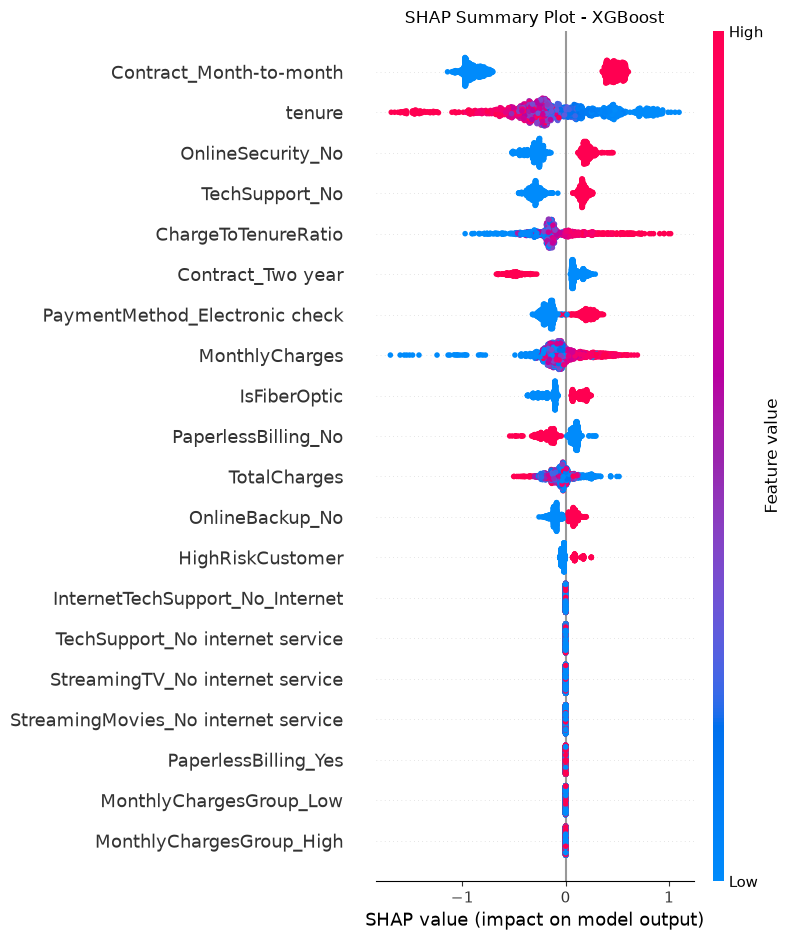

In [123]:
# shap summary plot
shap.summary_plot(shap_values, X_shap, show=False)
plt.title("SHAP Summary Plot - XGBoost")
plt.tight_layout()
plt.savefig("../models/shap/shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

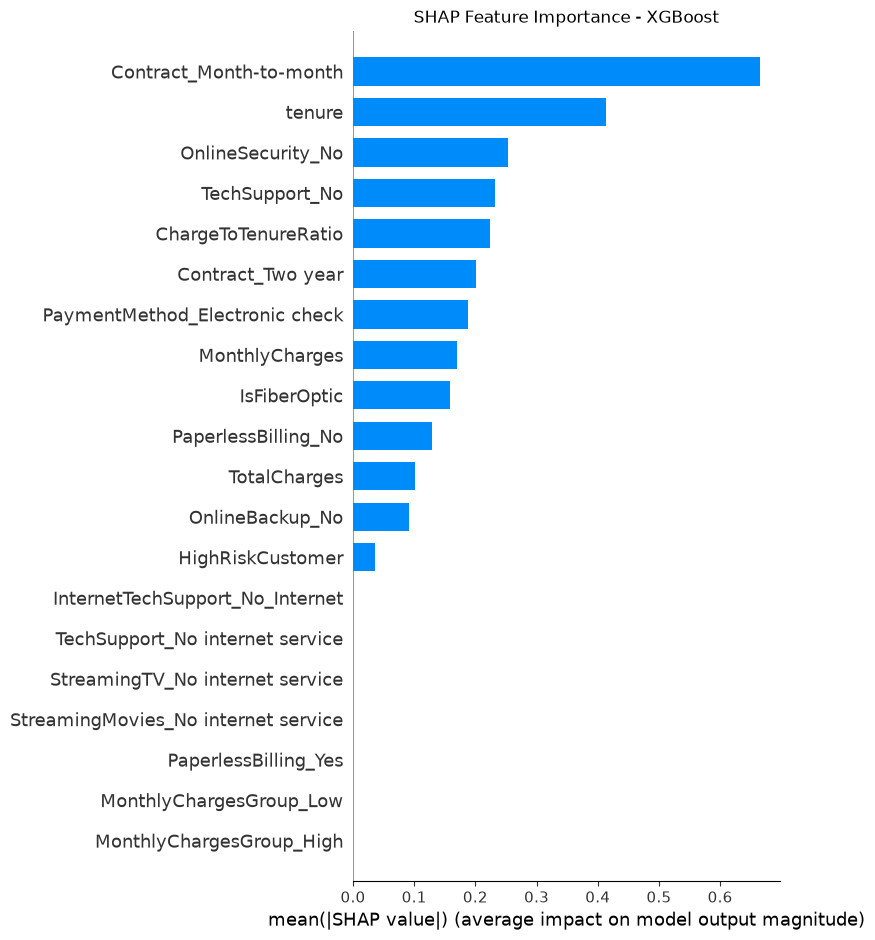

In [124]:
# shap Feature Importance

shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
plt.title("SHAP Feature Importance - XGBoost")
plt.tight_layout()
plt.savefig("../models/shap/shap_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

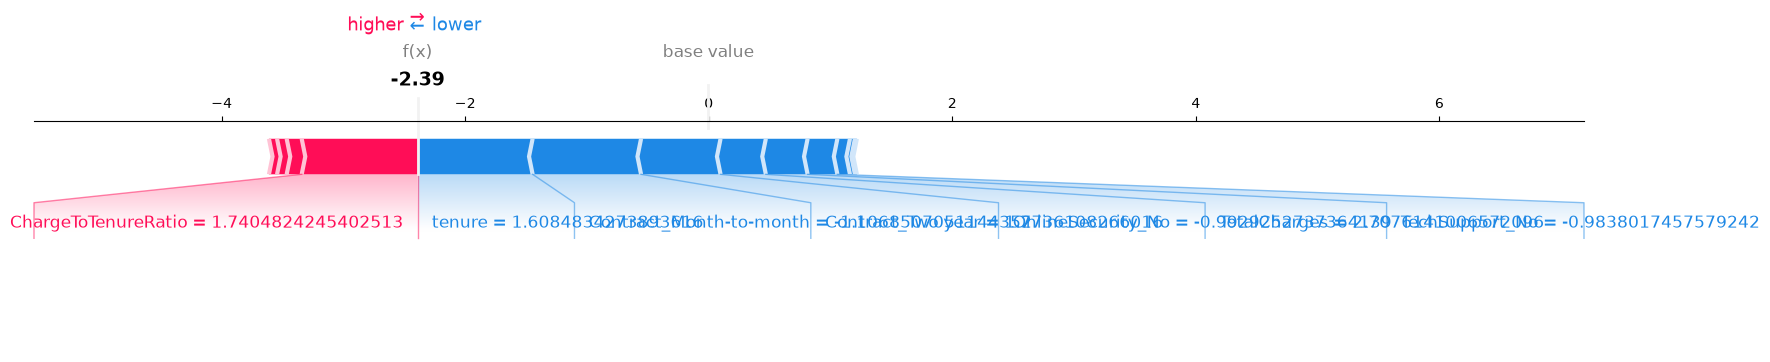

<Figure size 640x480 with 0 Axes>

In [126]:
# Individual Customer Explanation

customer_index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[customer_index],
    X_shap.iloc[customer_index],
    matplotlib=True
)
plt.savefig("../models/shap/individual_customer_explanation.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [127]:
print("Number of features:", X_shap.shape[1])
print(X_shap.columns.tolist())

Number of features: 30
['tenure', 'MonthlyCharges', 'TotalCharges', 'IsFiberOptic', 'NoInternet', 'ChargeToTenureRatio', 'HighRiskCustomer', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'TechSupport_No', 'TechSupport_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service', 'Contract_Month-to-month', 'Contract_Two year', 'PaperlessBilling_No', 'PaperlessBilling_Yes', 'PaymentMethod_Electronic check', 'TenureGroup_New Customer', 'TenureGroup_Very Long Term', 'MonthlyChargesGroup_High', 'MonthlyChargesGroup_Low', 'InternetTechSupport_Internet_Without_Support', 'InternetTechSupport_No_Internet']


In [135]:
print("Number of columns:", len(X_shap.columns))
print("Number of SHAP values:", shap_values.shape[1])

shap_df = pd.DataFrame({
    "Feature": X_shap.columns,
    "Importance": np.mean(np.abs(shap_values), axis=0)
})

print(shap_df.shape)
print(shap_df.to_string(index=False))

Number of columns: 30
Number of SHAP values: 30
(30, 2)
                                     Feature  Importance
                                      tenure    0.414063
                              MonthlyCharges    0.169529
                                TotalCharges    0.101624
                                IsFiberOptic    0.157787
                                  NoInternet    0.000000
                         ChargeToTenureRatio    0.223253
                            HighRiskCustomer    0.036279
                 InternetService_Fiber optic    0.000000
                          InternetService_No    0.000000
                           OnlineSecurity_No    0.253025
          OnlineSecurity_No internet service    0.000000
                             OnlineBackup_No    0.091105
            OnlineBackup_No internet service    0.000000
                         DeviceProtection_No    0.000000
        DeviceProtection_No internet service    0.000000
                              Te

#### SHAP analysis was performed on the final XGBoost model using 30 selected features. Among them, 13 features had non-zero SHAP contributions and influenced churn predictions. Contract type, tenure, online security, technical support, and charge-related features were the most influential factors.

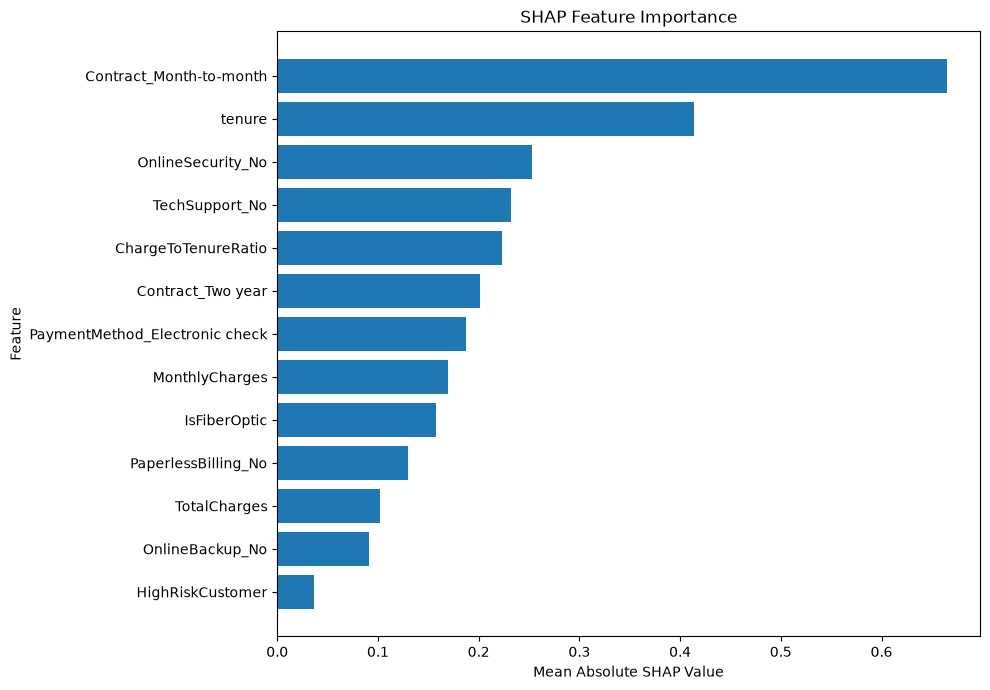

In [137]:
shap_df = shap_df[shap_df["Importance"] > 0]

# Sort for horizontal bar chart
shap_df = shap_df.sort_values("Importance", ascending=True)

# Plot
plt.figure(figsize=(10, 7))
plt.barh(shap_df["Feature"], shap_df["Importance"])
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.savefig("../models/shap/shap_nonzerofeature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [146]:
joblib.dump(selector_xgb_final, "../models/xgb_feature_selector.pkl")

['../models/xgb_feature_selector.pkl']

In [147]:
pd.DataFrame({"Feature": selected_features}).to_csv("../models/xgb_selected_features.csv", index=False)
print("Selected features saved.")

Selected features saved.
